# Customer Churn Prediction

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
encoder=LabelEncoder()

for col in df.columns:

    if df[col].dtype=="object":

        df[col]=encoder.fit_transform(df[col])

In [5]:
X=df.drop("Churn",axis=1)

y=df["Churn"]

In [6]:
X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.2,

random_state=42)

In [7]:
lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_lr))

Accuracy: 0.8204400283889283


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_rf))

Accuracy: 0.7970191625266146


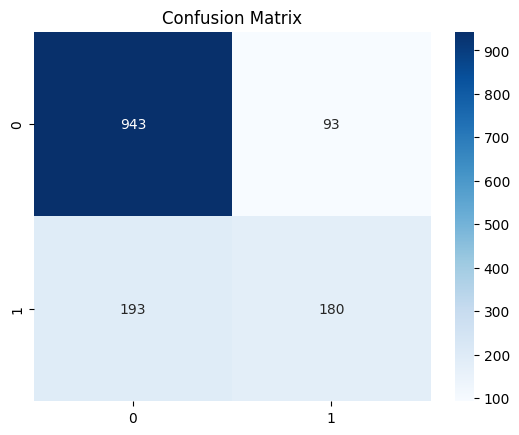

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test,pred_rf),

annot=True,

fmt='d',

cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

In [10]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.80      0.79      1409



In [9]:
import joblib

joblib.dump(rf,"churn_model.pkl")

['churn_model.pkl']

# Conclusion

Two machine learning models were trained.

Random Forest achieved better predictive performance and has been selected for deployment in the Streamlit dashboard.